<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #4f46e5; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        k-Nearest Neighbors (k-NN) en Clasificación y Regresión 🧭👥
      </h1>
      <p style="margin: 6px 0 0 0; color: #4f46e5; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Instance-Based Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #4338ca; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 02 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #4f46e5; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/02%20-%20Clasificacion%20y%20Regresion/01_K_Nearest_Neighbors_Clasificacion_y_Regresion.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Aprendizaje Basado en Instancias (*Lazy Learning*) 🏘️

k-Nearest Neighbors (k-NN) es el algoritmo de **aprendizaje perezoso** por excelencia: no ajusta ningún parámetro durante `fit` (simplemente almacena el conjunto de entrenamiento, $O(1)$); toda la "inteligencia" ocurre en el momento de predecir ($O(N \cdot D)$ por cada predicción, con $N$ observaciones de entrenamiento y $D$ variables), cuando busca los $k$ vecinos más cercanos a la nueva observación según alguna métrica de distancia.

La regla de predicción es la **misma idea** aplicada a dos tipos de variable objetivo distintos:

| | Clasificación (`KNeighborsClassifier`) | Regresión (`KNeighborsRegressor`) |
|---|---|---|
| **Predicción** | Voto mayoritario entre las clases de los $k$ vecinos. | Promedio (o promedio ponderado) del valor objetivo de los $k$ vecinos. |
| **Ejemplo en este cuaderno** | `riesgo_default` sobre `clientes_credito.csv`. | `precio_millones` sobre `inmuebles_precios.csv`. |

Ambos casos se trabajan en este cuaderno con los mismos tres ingredientes: una métrica de distancia (Sección 2), variables en la misma escala (Sección 3, **no negociable**) y un valor de $k$ elegido con criterio (Sección 7).

In [10]:
import os, sys, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "clientes_credito.csv": "...",
    "inmuebles_precios.csv": "...",
    "transacciones_fraude.csv": "...",
}

def load_dataset(filename: str) -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("02 - Clasificacion y Regresion", "data", filename),
        os.path.join("Data Mining", "02 - Clasificacion y Regresion", "data", filename),
        os.path.join("..", "02 - Clasificacion y Regresion", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/02%20-%20Clasificacion%20y%20Regresion/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        urllib.request.urlretrieve(url, target, timeout=3)
        return target
    except Exception:
        pass
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import os

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

credito = pd.read_csv(load_dataset("clientes_credito.csv"))
inmuebles = pd.read_csv(load_dataset("inmuebles_precios.csv"))

print(f"clientes_credito.csv   -> {credito.shape[0]} filas x {credito.shape[1]} columnas")
print(f"inmuebles_precios.csv  -> {inmuebles.shape[0]} filas x {inmuebles.shape[1]} columnas")
print("\nk-NN importado con exito.")

clientes_credito.csv   -> 1200 filas x 7 columnas
inmuebles_precios.csv  -> 1500 filas x 7 columnas

k-NN importado con exito.


---
## 2. La Familia de Distancias de Minkowski 📐

La distancia de Minkowski entre dos puntos $x, z \in \mathbb{R}^D$ generaliza, con un único parámetro $p \geq 1$, las métricas de distancia más usadas en k-NN:

$$d_p(x, z) = \left( \sum_{j=1}^{D} |x_j - z_j|^p \right)^{1/p}$$

| $p$ | Nombre | Fórmula resultante | Intuición geométrica |
|---|---|---|---|
| $p = 1$ | **Distancia Manhattan** (`cityblock`) | $\sum_j \lvert x_j - z_j \rvert$ | Distancia recorrida moviéndose solo en ángulos rectos (como cuadras de una ciudad). |
| $p = 2$ | **Distancia Euclidiana** | $\sqrt{\sum_j (x_j - z_j)^2}$ | La distancia "en línea recta" habitual; es el valor por defecto de `KNeighborsClassifier`/`Regressor` (`p=2`). |
| $p \to \infty$ | **Distancia Chebyshev** | $\max_j \lvert x_j - z_j \rvert$ | La mayor diferencia en una sola coordenada termina dominando por completo. |

A medida que $p$ crece, la distancia de Minkowski se acerca cada vez más al máximo de las diferencias absolutas por coordenada, penalizando cada vez menos las diferencias en las demás variables. La siguiente celda calcula varias de ellas para un par de puntos concreto.

In [11]:
punto_a = np.array([2, 3])
punto_b = np.array([5, 7])

for p in [1, 2, 3, 10]:
    distancia = np.sum(np.abs(punto_a - punto_b) ** p) ** (1 / p)
    nombre = {1: "Manhattan", 2: "Euclidiana"}.get(p, f"Minkowski p={p}")
    print(f"p={p:>2} ({nombre:11s}): d = {distancia:.4f}")

p= 1 (Manhattan  ): d = 7.0000
p= 2 (Euclidiana ): d = 5.0000
p= 3 (Minkowski p=3): d = 4.4979
p=10 (Minkowski p=10): d = 4.0220


---
## 3. El Prerrequisito Crítico: Escalar las Variables 🎚️

k-NN es un algoritmo **basado enteramente en distancias** (Sección 2): la distancia entre dos observaciones es una suma sobre todas las variables, y **cualquier variable con una escala numérica mayor domina esa suma**, sin importar si esa variable es más o menos informativa que las demás. Este problema ya se trabajó en el **Módulo 01** con `StandardScaler`/`RobustScaler` al preparar datos para modelos sensibles a escala — k-NN es, junto con la regresión regularizada, el ejemplo canónico de por qué ese paso no es opcional.

`clientes_credito.csv` es un caso de manual: `ingreso_mensual` se mueve en millones de pesos (desviación estándar ≈1.69M) mientras que `ratio_deuda_ingreso` vive en el rango $[0, 1]$ (desviación estándar ≈0.20). Sin escalar, una diferencia de \$500,000 en ingreso —posiblemente poco relevante— pesa infinitamente más en la distancia euclidiana que una diferencia de 0.3 en el ratio de deuda —que sí podría ser decisiva para el riesgo de incumplimiento.

In [12]:
feat_cols_cred = ["edad", "ingreso_mensual", "antiguedad_laboral_meses", "score_credito", "ratio_deuda_ingreso"]
X_cred = credito[feat_cols_cred]
y_cred = credito["riesgo_default"]

print("Escalas muy distintas entre variables (media y desviacion estandar):")
display(X_cred.agg(["mean", "std"]).round(3))

Xtr, Xte, ytr, yte = train_test_split(X_cred, y_cred, test_size=0.25, random_state=42, stratify=y_cred)

# SIN escalar
knn_sin_escalar = KNeighborsClassifier(n_neighbors=5).fit(Xtr, ytr)
acc_sin_escalar = accuracy_score(yte, knn_sin_escalar.predict(Xte))

# CON StandardScaler (ajustado SOLO sobre train, para no filtrar informacion del test)
escalador = StandardScaler().fit(Xtr)
Xtr_esc = escalador.transform(Xtr)
Xte_esc = escalador.transform(Xte)
knn_con_escalar = KNeighborsClassifier(n_neighbors=5).fit(Xtr_esc, ytr)
acc_con_escalar = accuracy_score(yte, knn_con_escalar.predict(Xte_esc))

print(f"\nKNN (k=5) SIN escalar         -> accuracy = {acc_sin_escalar:.4f}")
print(f"KNN (k=5) CON StandardScaler  -> accuracy = {acc_con_escalar:.4f}")

Escalas muy distintas entre variables (media y desviacion estandar):


,edad,ingreso_mensual,antiguedad_laboral_meses,score_credito,ratio_deuda_ingreso
mean,44.134,"4,218,773.219",94.475,606.926,0.390
std,13.543,"1,688,951.666",49.781,141.778,0.201



KNN (k=5) SIN escalar         -> accuracy = 0.5067
KNN (k=5) CON StandardScaler  -> accuracy = 0.7100


**Lectura:** sin escalar, la accuracy (0.5067) es apenas superior a un lanzamiento de moneda — con `riesgo_default` casi balanceado (≈52%/48%), un modelo que ignorara por completo las variables no haría mucho peor. La razón es que `ingreso_mensual` (valores del orden de millones) domina completamente el cálculo de distancia frente a `ratio_deuda_ingreso` o `score_credito`, por lo que k-NN termina buscando "vecinos con ingreso parecido" e ignorando casi todo lo demás. Al escalar con `StandardScaler` (ajustado únicamente sobre el conjunto de entrenamiento, para no filtrar información del conjunto de prueba), la accuracy sube a **0.7100** — una mejora de más de 20 puntos porcentuales sin cambiar ni el algoritmo ni los datos, solo su escala. Esta es, con diferencia, la causa más común de un k-NN que "no funciona" en la práctica.

---
## 4. `KNeighborsClassifier` en la Práctica: Riesgo de Incumplimiento Crediticio 💳

Con las variables ya escaladas, se entrena el clasificador completo sobre `clientes_credito.csv` y se evalúa con `classification_report`, que desagrega la accuracy global en precisión y recall por clase (métricas que se profundizan en el Cuaderno 04).

In [13]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(Xtr_esc, ytr)
y_pred_clf = knn_clf.predict(Xte_esc)

print(f"Accuracy sobre el conjunto de prueba: {accuracy_score(yte, y_pred_clf):.4f}\n")
print("Reporte de clasificacion:")
print(classification_report(yte, y_pred_clf, target_names=["Sin riesgo (0)", "Riesgo default (1)"]))

Accuracy sobre el conjunto de prueba: 0.7100

Reporte de clasificacion:
                    precision    recall  f1-score   support

    Sin riesgo (0)       0.70      0.76      0.73       156
Riesgo default (1)       0.72      0.65      0.68       144

          accuracy                           0.71       300
         macro avg       0.71      0.71      0.71       300
      weighted avg       0.71      0.71      0.71       300



**Lectura:** con $k=5$ y variables escaladas, el modelo alcanza 71% de accuracy, con un recall algo menor para la clase de riesgo (65%: la proporción de clientes que sí incumplen y son detectados como tales) que para la clase sin riesgo (76%). No es un modelo perfecto -- ninguno de los tres datasets de este curso fue diseñado para serlo -- pero es un punto de partida razonable a partir de solo 5 variables numéricas y sin ningún ajuste de hiperparámetros todavía (eso llega en la Sección 7).

---
## 5. `KNeighborsRegressor` en la Práctica: Precio de Inmuebles 🏠

La misma idea de "vecinos parecidos" aplica a un objetivo continuo: en lugar de votar la clase más común, `KNeighborsRegressor` **promedia** el `precio_millones` de los $k$ inmuebles más parecidos (tras escalar, por las mismas razones de la Sección 3). Se compara además contra `LinearRegression` sobre las mismas variables, para verificar si k-NN aporta algo que un modelo lineal simple no capture.

In [14]:
feat_cols_inm = ["area_m2", "habitaciones", "estrato", "antiguedad_anios", "distancia_centro_km"]
X_inm = inmuebles[feat_cols_inm]
y_inm = inmuebles["precio_millones"]

Xtr_i, Xte_i, ytr_i, yte_i = train_test_split(X_inm, y_inm, test_size=0.25, random_state=42)
escalador_i = StandardScaler().fit(Xtr_i)
Xtr_i_esc = escalador_i.transform(Xtr_i)
Xte_i_esc = escalador_i.transform(Xte_i)

knn_reg = KNeighborsRegressor(n_neighbors=5).fit(Xtr_i_esc, ytr_i)
pred_knn = knn_reg.predict(Xte_i_esc)
r2_knn, rmse_knn = r2_score(yte_i, pred_knn), np.sqrt(mean_squared_error(yte_i, pred_knn))

reg_lineal = LinearRegression().fit(Xtr_i_esc, ytr_i)
pred_lineal = reg_lineal.predict(Xte_i_esc)
r2_lin, rmse_lin = r2_score(yte_i, pred_lineal), np.sqrt(mean_squared_error(yte_i, pred_lineal))

print(f"KNeighborsRegressor (k=5) -> R2 = {r2_knn:.4f}   RMSE = {rmse_knn:.2f} millones")
print(f"LinearRegression          -> R2 = {r2_lin:.4f}   RMSE = {rmse_lin:.2f} millones")

KNeighborsRegressor (k=5) -> R2 = 0.9593   RMSE = 38.21 millones
LinearRegression          -> R2 = 0.8894   RMSE = 62.96 millones


**Lectura:** `KNeighborsRegressor` ($R^2$=0.9593, RMSE≈38.2 millones) supera claramente a `LinearRegression` ($R^2$=0.8894, RMSE≈62.96 millones) sobre las mismas cinco variables escaladas. La razón más probable, visible en las correlaciones del Cuaderno 00, es que la relación entre `estrato` (o `distancia_centro_km`) y `precio_millones` no es puramente lineal (los saltos entre estratos socioeconómicos no son incrementos constantes en precio): k-NN, al no asumir ninguna forma funcional específica, puede capturar ese tipo de no linealidad "gratis", simplemente promediando entre inmuebles similares.

### 5.1 Visualizando las "Fronteras Continuas" del Vecindario 🔍

En clasificación, k-NN traza fronteras de decisión escalonadas entre regiones de clases distintas. En regresión, el equivalente es una **superficie de predicción localmente constante por tramos**: dentro de la vecindad de $k$ puntos de entrenamiento, la predicción no cambia; al cruzar hacia una vecindad distinta, salta. La siguiente celda aísla `area_m2` para visualizar ese efecto en una sola dimensión, en contraste con la recta suave de `LinearRegression`.

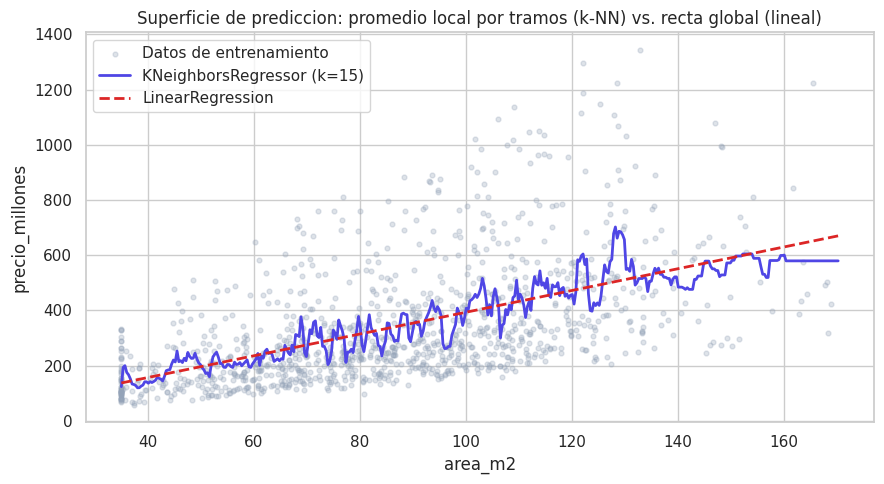

In [15]:
X_1d = inmuebles[["area_m2"]]
Xtr_1d, Xte_1d, ytr_1d, yte_1d = train_test_split(X_1d, y_inm, test_size=0.25, random_state=42)

knn_1d = KNeighborsRegressor(n_neighbors=15).fit(Xtr_1d, ytr_1d)
lineal_1d = LinearRegression().fit(Xtr_1d, ytr_1d)

grid_area = np.linspace(X_1d["area_m2"].min(), X_1d["area_m2"].max(), 400).reshape(-1, 1)
grid_area_df = pd.DataFrame(grid_area, columns=["area_m2"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(Xtr_1d["area_m2"], ytr_1d, s=12, alpha=0.3, color="#94a3b8", label="Datos de entrenamiento")
ax.plot(grid_area, knn_1d.predict(grid_area_df), color="#4f46e5", linewidth=2, label="KNeighborsRegressor (k=15)")
ax.plot(grid_area, lineal_1d.predict(grid_area_df), color="#dc2626", linewidth=2, linestyle="--", label="LinearRegression")
ax.set_xlabel("area_m2")
ax.set_ylabel("precio_millones")
ax.set_title("Superficie de prediccion: promedio local por tramos (k-NN) vs. recta global (lineal)")
ax.legend()
plt.tight_layout()
plt.show()

La curva de k-NN no es una recta ni una curva suave: es una sucesión de **escalones**, cada uno correspondiente a una vecindad distinta de 15 inmuebles. Esa es la naturaleza de un método no paramétrico basado en promedios locales -- "fronteras continuas" en el sentido de que no hay una ecuación cerrada de por medio, pero visualmente discontinuas en su derivada. `LinearRegression`, en cambio, está forzada a una única pendiente global, sin importar si esta se ajusta mejor en una zona del rango de `area_m2` que en otra.

---
## 6. Ponderación Espacial: `weights='distance'` vs. `weights='uniform'` ⚖️

Por defecto (`weights='uniform'`), los $k$ vecinos contribuyen **por igual** al voto o al promedio, sin importar si un vecino está a una distancia mínima o casi en el borde del vecindario. `weights='distance'` corrige esto ponderando la contribución de cada vecino por el inverso de su distancia ($1/d$): los vecinos más cercanos —presumiblemente más parecidos, y por tanto más informativos— pesan más que los lejanos. A esta idea se le llama aquí **ponderación espacial**, porque el peso de cada voto depende explícitamente de dónde cae ese vecino en el espacio de variables.

In [16]:
print("--- Clasificacion (riesgo_default, k=5) ---")
for peso in ["uniform", "distance"]:
    modelo = KNeighborsClassifier(n_neighbors=5, weights=peso).fit(Xtr_esc, ytr)
    acc = accuracy_score(yte, modelo.predict(Xte_esc))
    print(f"  weights='{peso}': accuracy = {acc:.4f}")

print("\n--- Regresion (precio_millones, k=5) ---")
for peso in ["uniform", "distance"]:
    modelo = KNeighborsRegressor(n_neighbors=5, weights=peso).fit(Xtr_i_esc, ytr_i)
    pred = modelo.predict(Xte_i_esc)
    r2 = r2_score(yte_i, pred)
    rmse = np.sqrt(mean_squared_error(yte_i, pred))
    print(f"  weights='{peso}': R2 = {r2:.4f}   RMSE = {rmse:.2f}")

--- Clasificacion (riesgo_default, k=5) ---
  weights='uniform': accuracy = 0.7100
  weights='distance': accuracy = 0.7133

--- Regresion (precio_millones, k=5) ---
  weights='uniform': R2 = 0.9593   RMSE = 38.21
  weights='distance': R2 = 0.9640   RMSE = 35.94


**Lectura:** en ambos casos `weights='distance'` iguala o mejora ligeramente a `weights='uniform'` (accuracy 0.7100 → 0.7133; $R^2$ 0.9593 → 0.9640, RMSE 38.20 → 35.94 millones). La mejora es modesta pero consistente con la intuición: al ponderar por distancia, un vecino casi idéntico a la observación de consulta domina la predicción, mientras que un vecino en el borde del vecindario -- que podría pertenecer casi tanto a la vecindad contigua -- aporta menos. La ganancia suele ser mayor cuando $k$ es grande (más vecinos "lejanos" entran a votar) o cuando la densidad de puntos no es uniforme en el espacio de variables.

---
## 7. Eligiendo $k$: el Sesgo-Varianza Propio de k-NN 🎯

$k$ es el hiperparámetro más importante de k-NN, y controla directamente el mismo dilema sesgo-varianza del Cuaderno 00:

* **$k$ pequeño** (extremo: $k=1$): el modelo sigue cada punto de entrenamiento individualmente -- **alta varianza**, frontera de decisión (o superficie de predicción) muy irregular, alto riesgo de sobreajuste al ruido.
* **$k$ grande** (extremo: $k=N$): la predicción se acerca a un promedio/voto global, ignorando la estructura local -- **alto sesgo**, frontera casi constante, subajuste.

El valor óptimo está en algún punto intermedio, y se identifica empíricamente comparando el error de entrenamiento y de prueba a través de un rango de valores de $k$ (un "barrido" o *k-sweep*).

,k,accuracy_train,accuracy_test
0,1,1.000,0.653
1,3,0.819,0.693
2,5,0.773,0.710
3,7,0.752,0.733
4,9,0.758,0.750
5,11,0.758,0.730
6,15,0.758,0.747
7,21,0.761,0.743
8,31,0.761,0.753
9,51,0.757,0.753


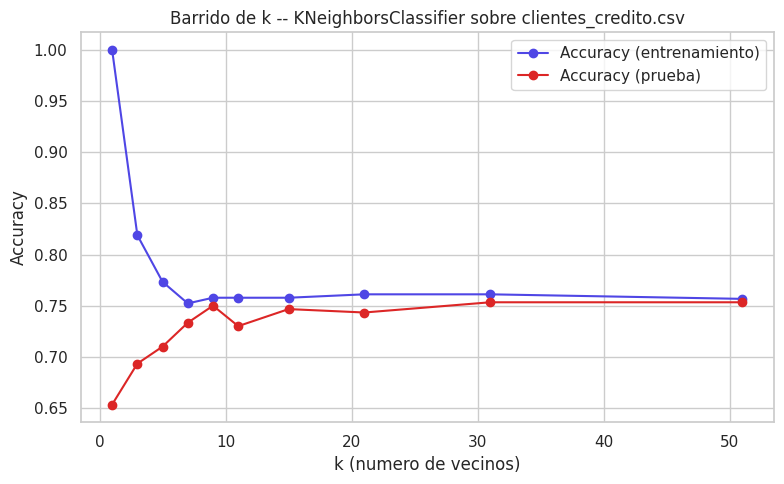

In [17]:
valores_k = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]
acc_train, acc_test = [], []

for k in valores_k:
    modelo_k = KNeighborsClassifier(n_neighbors=k).fit(Xtr_esc, ytr)
    acc_train.append(accuracy_score(ytr, modelo_k.predict(Xtr_esc)))
    acc_test.append(accuracy_score(yte, modelo_k.predict(Xte_esc)))

barrido_k = pd.DataFrame({"k": valores_k, "accuracy_train": acc_train, "accuracy_test": acc_test})
display(barrido_k.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(valores_k, acc_train, marker="o", color="#4f46e5", label="Accuracy (entrenamiento)")
ax.plot(valores_k, acc_test, marker="o", color="#dc2626", label="Accuracy (prueba)")
ax.set_xlabel("k (numero de vecinos)")
ax.set_ylabel("Accuracy")
ax.set_title("Barrido de k -- KNeighborsClassifier sobre clientes_credito.csv")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura:** con $k=1$ la accuracy de entrenamiento es perfecta (1.0000, cada punto es su propio vecino más cercano) pero la de prueba es la más baja del barrido (0.6533) -- el patrón exacto de alta varianza. A medida que $k$ crece, la brecha train-test se cierra y la accuracy de prueba mejora hasta estabilizarse alrededor de $k=9$ a $k=31$ (≈0.73-0.75), sin mostrar en este dataset el descenso adicional que sí podría observarse con más variables ruidosas o un rango de $k$ más amplio ($k=31$ y $k=51$ quedan prácticamente empatados en 0.7533). En este dataset, valores de $k$ entre 9 y 31 ofrecen el mejor equilibrio -- y ese rango, en un flujo de trabajo real, se elegiría formalmente con `GridSearchCV` y validación cruzada (Cuaderno 00, Sección 5), nunca mirando directamente el conjunto de prueba.

---
## 8. Consideraciones Prácticas y Limitaciones 🧭

| Consideración | Descripción | Mitigación |
|---|---|---|
| **Maldición de la dimensionalidad** (*curse of dimensionality*) | Con muchas variables, todos los puntos tienden a quedar aproximadamente equidistantes entre sí; la noción de "vecino cercano" pierde significado. | Reducción de dimensionalidad (PCA), selección de variables, evitar incluir variables redundantes o irrelevantes. |
| **Costo computacional en predicción** | A diferencia de un modelo paramétrico (que predice con una fórmula fija), k-NN debe calcular la distancia a **todos** los $N$ puntos de entrenamiento por cada predicción nueva ($O(N \cdot D)$). | Estructuras de indexación espacial (`KDTree`, `BallTree`, ya usadas internamente por `sklearn` cuando es posible), reducir $N$ mediante muestreo. |
| **Sensibilidad a variables irrelevantes o ruidosas** | Cualquier variable incluida participa en el cálculo de distancia, incluso si no tiene relación real con el objetivo -- diluye la señal de las variables que sí importan. | Selección de variables previa; en este curso, revisar correlaciones (Cuaderno 00) antes de entrenar. |
| **Requiere escalado obligatorio** | Ya demostrado en la Sección 3: sin escalar, la variable de mayor magnitud domina por completo la distancia. | `StandardScaler` o `RobustScaler` (Módulo 01), siempre ajustados solo sobre el conjunto de entrenamiento. |
| **Sin modelo interpretable explícito** | No hay coeficientes ni reglas que expliquen la predicción -- solo "estos son los vecinos más parecidos". | Inspeccionar directamente los $k$ vecinos usados (`kneighbors()`) como forma de explicación caso por caso. |

**Regla práctica:** k-NN es un excelente punto de partida no lineal, rápido de entender e implementar, pero rara vez es la opción de producción final en datasets de alta dimensionalidad o gran volumen -- ahí compiten árboles, ensambles y modelos lineales regularizados, que se cubren en cuadernos posteriores del módulo.

---
## 9. Ejercicio Práctico Guiado: Eligiendo $k$ para `KNeighborsRegressor` 📝

**Contexto:** en la Sección 5 se usó $k=5$ para `KNeighborsRegressor` sobre `inmuebles_precios.csv` sin justificar esa elección. Vas a repetir el barrido de la Sección 7, esta vez para el problema de regresión, y a identificar el valor de $k$ que minimiza el RMSE sobre el conjunto de prueba.

**Tu misión:**
1. Recorre `k` en `range(1, 32)`.
2. Para cada `k`, entrena un `KNeighborsRegressor(n_neighbors=k)` sobre `Xtr_i_esc`/`ytr_i` (ya definidos en la Sección 5).
3. Calcula el RMSE sobre el conjunto de prueba (`Xte_i_esc`/`yte_i`) para cada `k`.
4. Guarda los resultados en una lista o `DataFrame` y determina cuál `k` produce el RMSE de prueba más bajo.
5. Imprime ese `k` óptimo junto con su RMSE.

In [18]:
### TU CODIGO AQUI ###
resultados_rmse = []

for k in range(1, 32):
    # 1-2. Entrena un KNeighborsRegressor con este k sobre los datos escalados de entrenamiento
    modelo = None
    # 3. Calcula el RMSE sobre el conjunto de prueba
    rmse_k = None
    resultados_rmse.append({"k": k, "rmse_test": rmse_k})

# 4. Convierte a DataFrame y encuentra el k con menor RMSE de prueba
df_rmse = None
mejor_fila = None

# 5. Imprime el resultado
print("Mejor k:", None)
print("RMSE de prueba en el mejor k:", None)

Mejor k: None
RMSE de prueba en el mejor k: None


<details>
<summary>💡 Ver solución propuesta</summary>

```python
resultados_rmse = []

for k in range(1, 32):
    # 1-2. Entrena un KNeighborsRegressor con este k sobre los datos escalados de entrenamiento
    modelo = KNeighborsRegressor(n_neighbors=k).fit(Xtr_i_esc, ytr_i)
    # 3. Calcula el RMSE sobre el conjunto de prueba
    rmse_k = np.sqrt(mean_squared_error(yte_i, modelo.predict(Xte_i_esc)))
    resultados_rmse.append({"k": k, "rmse_test": rmse_k})

# 4. Convierte a DataFrame y encuentra el k con menor RMSE de prueba
df_rmse = pd.DataFrame(resultados_rmse)
mejor_fila = df_rmse.loc[df_rmse["rmse_test"].idxmin()]

# 5. Imprime el resultado
print("Mejor k:", int(mejor_fila["k"]))
print("RMSE de prueba en el mejor k:", round(mejor_fila["rmse_test"], 3))
```

En este dataset, el RMSE de prueba desciende rápidamente entre $k=1$ (fuerte sobreajuste, cada predicción depende de un único inmueble) y $k \approx 4$-$5$, para luego subir de nuevo de forma sostenida a medida que $k$ sigue creciendo y el modelo empieza a promediar entre inmuebles cada vez menos parecidos -- la misma forma de "U" del barrido de accuracy en la Sección 7, ahora en términos de error en vez de exactitud.

</details>

---
## 10. Resumen Ejecutivo del Cuaderno 01 📌

1. **k-NN es un único algoritmo con dos salidas:** voto mayoritario para clasificación (`KNeighborsClassifier`), promedio local para regresión (`KNeighborsRegressor`), ambos basados en distancia entre observaciones.
2. **La distancia de Minkowski generaliza Manhattan ($p=1$) y Euclidiana ($p=2$)** como casos particulares de una misma fórmula; `sklearn` usa Euclidiana por defecto.
3. **Escalar las variables no es opcional:** sin `StandardScaler`, la accuracy de `KNeighborsClassifier` sobre `clientes_credito.csv` fue de apenas 0.5067 (casi azar); con escalado, subió a 0.7100 -- más de 20 puntos porcentuales de mejora sin cambiar el algoritmo.
4. **k-NN puede superar a un modelo lineal cuando hay no linealidades:** sobre `inmuebles_precios.csv`, `KNeighborsRegressor` ($R^2$=0.9593) superó a `LinearRegression` ($R^2$=0.8894) con las mismas variables.
5. **`weights='distance'` aporta una mejora consistente pero modesta** frente a `weights='uniform'` (accuracy 0.7100→0.7133; $R^2$ 0.9593→0.9640) al dar más peso a los vecinos más cercanos.
6. **$k$ controla el propio dilema sesgo-varianza de k-NN:** $k$ pequeño sobreajusta (accuracy de prueba mínima en $k=1$: 0.6533, pese a accuracy de entrenamiento perfecta), $k$ grande subajusta; el óptimo empírico en este dataset estuvo entre $k=9$ y $k=31$ para clasificación, y cerca de $k=4$-$5$ para la regresión de precios.
7. **Siguiente paso:** el **Cuaderno 02** introduce **regresión logística**, un modelo paramétrico y directamente interpretable que contrasta con la naturaleza no paramétrica y "perezosa" de k-NN.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Clasificación y Regresión</i>
  </p>
</div>